In [1]:
from dotenv import load_dotenv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sqlalchemy import create_engine
import os
import utils
import datetime

In [2]:
load_dotenv()
# f"postgres+psycopg2://{[user]}:{[pass]}@{[host}:{[port]}/{[dbname]}"
engine = create_engine(
    f"postgresql+psycopg2://{os.getenv('POSTGRES_USER')}:{os.getenv('POSTGRES_PASSWORD')}"
    f"@{os.getenv('POSTGRES_HOST')}:{os.getenv('POSTGRES_PORT')}/{os.getenv('POSTGRES_DB')}"
)

In [3]:
start_time='08:00:00'
end_time='15:30:00'
query_min = "SELECT * FROM silver.es_bars WHERE bar_time BETWEEN %(start)s AND %(end)s ORDER BY bar_date, bar_time"
query_swings = "SELECT * FROM silver.es_swings WHERE time_start BETWEEN %(start)s AND %(end)s ORDER BY date, time_start"
df_min = pd.read_sql(query_min,engine, params={"start": start_time, "end": end_time})
df_swings = pd.read_sql(query_swings,engine, params={"start": start_time, "end": end_time})

In [4]:
df_min = utils.add_winsorized_col(df_min,'volume')
utils.create_time_bucket(df_min,'bar_time','30')
utils.create_time_bucket(df_min,'bar_time','15')
utils.create_time_bucket(df_min,'bar_time','5')

utils.create_time_bucket(df_swings,'time_start','30')
utils.create_time_bucket(df_swings,'time_start','15')
utils.create_time_bucket(df_swings,'time_start','5')

In [5]:
df_swings['profit'] = np.where(
    df_swings['trend']=='UP', 
    abs(df_swings['open']-df_swings['high']), 
    abs(df_swings['open']-df_swings['low'])
)
df_swings = utils.add_winsorized_col(df_swings,'profit')

In [6]:
df_30 = df_min.groupby(['bar_date','bucket_30min'])[['volume','volume_winsorized']].agg('sum').reset_index()
df_15 = df_min.groupby(['bar_date','bucket_15min'])[['volume','volume_winsorized']].agg('sum').reset_index()
df_5 = df_min.groupby(['bar_date','bucket_5min'])[['volume','volume_winsorized']].agg('sum').reset_index()

#df_swings_30 = df_min.groupby(['bar_date','bucket_30min'])[['volume','volume_winsorized']].agg('sum').reset_index()
#df_swings_15 = df_min.groupby(['bar_date','bucket_15min'])[['volume','volume_winsorized']].agg('sum').reset_index()
#df_swings_5 = df_min.groupby(['bar_date','bucket_5min'])[['volume','volume_winsorized']].agg('sum').reset_index()

30 Min Bucket Analysis

In [7]:
agg_30_volume = utils.descriptive_groupby(df_30,'bucket_30min','volume')
agg_30_volume_win = utils.descriptive_groupby(df_30,'bucket_30min','volume_winsorized')

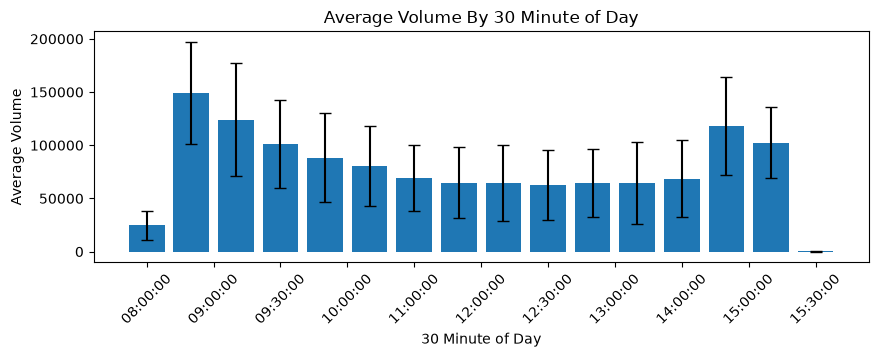

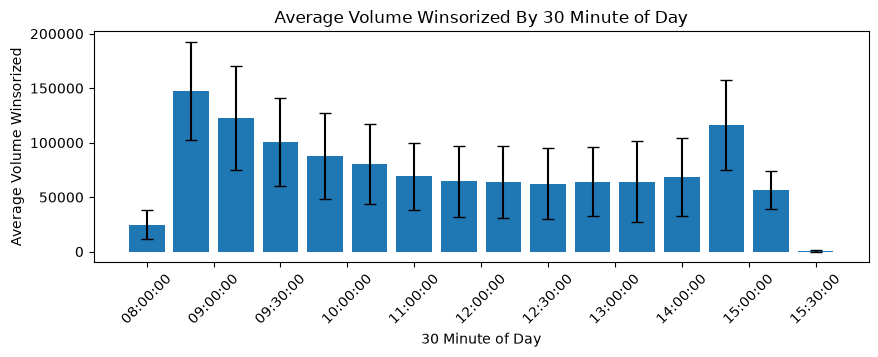

In [8]:
utils.bar_chart(agg_30_volume,'mean','30 Minute of Day','Average Volume',tickbin=16,yerror=agg_30_volume['std'])
utils.bar_chart(agg_30_volume_win,'mean','30 Minute of Day','Average Volume Winsorized',tickbin=16,yerror=agg_30_volume_win['std'])

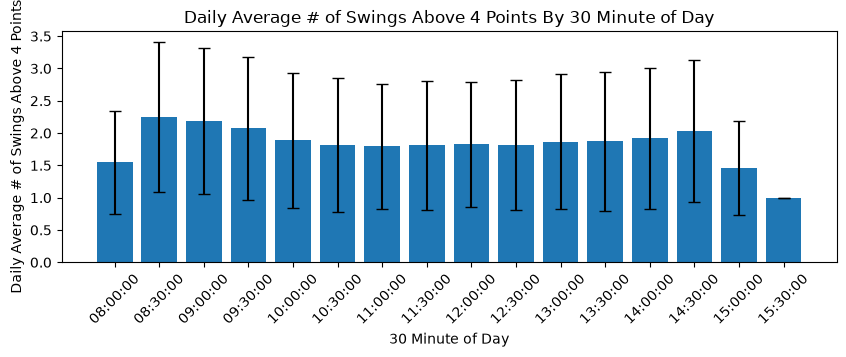

In [28]:
points_target = 4
diff = pd.to_timedelta(df_swings['time_end'].astype(str)) - pd.to_timedelta(df_swings['time_start'].astype(str))
df_swings_limit = df_swings[(df_swings['profit_winsorized'] >= points_target) & (diff.dt.total_seconds() > 60)]

#utils.descriptive_analysis(df_swings_limit[df_swings_limit['bucket_30min']=='08:30:00'],'profit_winsorized')
agg_swings_limit = utils.descriptive_groupby(df_swings_limit,['date','bucket_30min'],'profit_winsorized')
agg_swings_average_limit_daily = utils.descriptive_groupby(agg_swings_limit,['bucket_30min'],'count')
#agg_swings_average_limit_daily['mean'] = np.floor(agg_swings_average_limit_daily['mean'])
utils.bar_chart(agg_swings_average_limit_daily,'mean','30 Minute of Day',f'Daily Average # of Swings Above {points_target} Points',yerror=agg_swings_average_limit_daily['std'])

In [29]:
utils.descriptive_analysis(df_swings_limit,'profit_winsorized')
agg_swings_average_limit_daily

count    25709.000000
mean         7.534764
std          3.271467
min          4.000000
25%          5.000000
50%          6.500000
75%          9.250000
max         14.500000
Name: profit_winsorized, dtype: float64

Median:  6.5
Std Dev:  3.271466800178428
IQR:  4.25


,mean,median,std,count
bucket_30min,,,,
08:00:00,1.544928,1.0,0.791012,690
08:30:00,2.249788,2.0,1.155427,1181
09:00:00,2.186396,2.0,1.129803,1132
09:30:00,2.072312,2.0,1.112913,1051
10:00:00,1.888098,2.0,1.040763,983
10:30:00,1.818664,2.0,1.034434,943
11:00:00,1.792541,2.0,0.961980,858
11:30:00,1.808729,2.0,1.002888,779
12:00:00,1.827503,2.0,0.969544,829


1 Minute Analysis

In [22]:
df_min = utils.add_winsorized_col(df_min,'volume')

agg_min_volume = utils.descriptive_groupby(df_min,'bar_time','volume')
agg_min_volume_win = utils.descriptive_groupby(df_min,'bar_time','volume_winsorized')

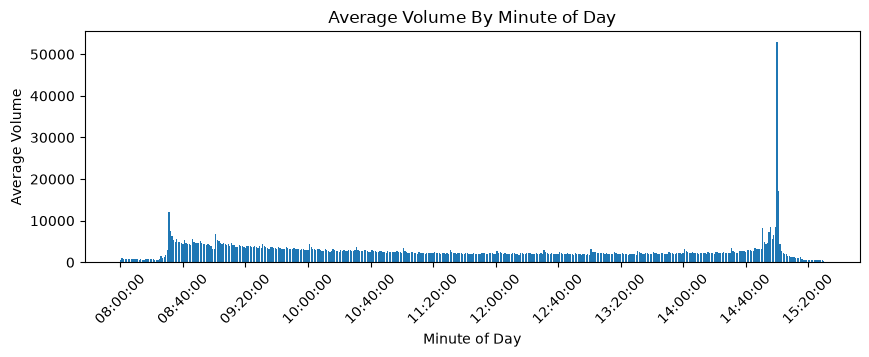

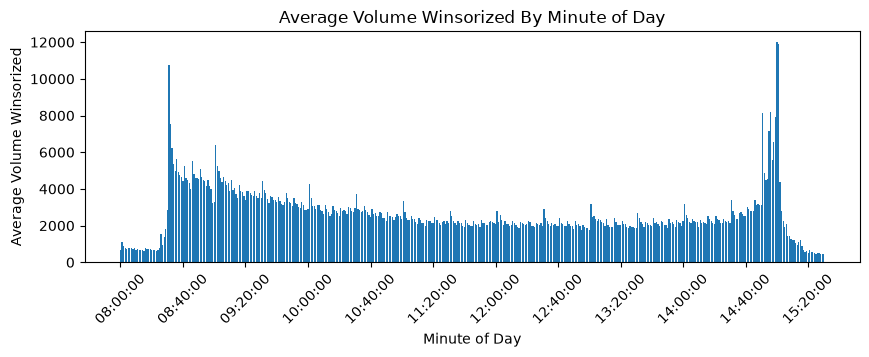

In [23]:
utils.bar_chart(agg_min_volume,'mean','Minute of Day','Average Volume',tickbin=16)
utils.bar_chart(agg_min_volume_win,'mean','Minute of Day','Average Volume Winsorized',tickbin=16)